> <div class = 'markdown-google-sans'>
> <h1>Neural Network Performance Improvement - Data Scaling</h1>1. Improved Convergence:
Effect on Training: Scaling data ensures that all input features have a similar scale or range. This is crucial because neural networks typically converge faster when input features are normalized. If features are on different scales, the optimization process can become inefficient, requiring more iterations to converge or even leading to poor convergence.
<br><br>
2. Enhanced Gradient Descent: Effect on Learning: Data scaling helps in stabilizing and accelerating the gradient descent algorithm. When features are on different scales, the gradients can vary widely in magnitude, leading to unstable or inefficient updates. Scaling ensures that gradients are of similar magnitude, which improves the stability and efficiency of the training process.
Avoiding Numerical Issues:
<br><br>
3. Effect on Computation: Neural networks involve a lot of matrix operations, and having features with vastly different scales can lead to numerical instability. Scaling reduces the risk of overflow and underflow during computations, helping maintain numerical precision.
Regularization and Activation Functions:
<br><br>
4. Effect on Activation Functions: Many activation functions, such as sigmoid or tanh, assume inputs within a specific range. If input values are too large or too small, the activations might saturate, leading to slow learning or vanishing gradients. Proper scaling helps keep inputs within the ideal range for these functions.

In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

In [17]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes = 2,
    n_clusters_per_class=1,
    class_sep=0.3,
    random_state=42
)

X = X * 10000

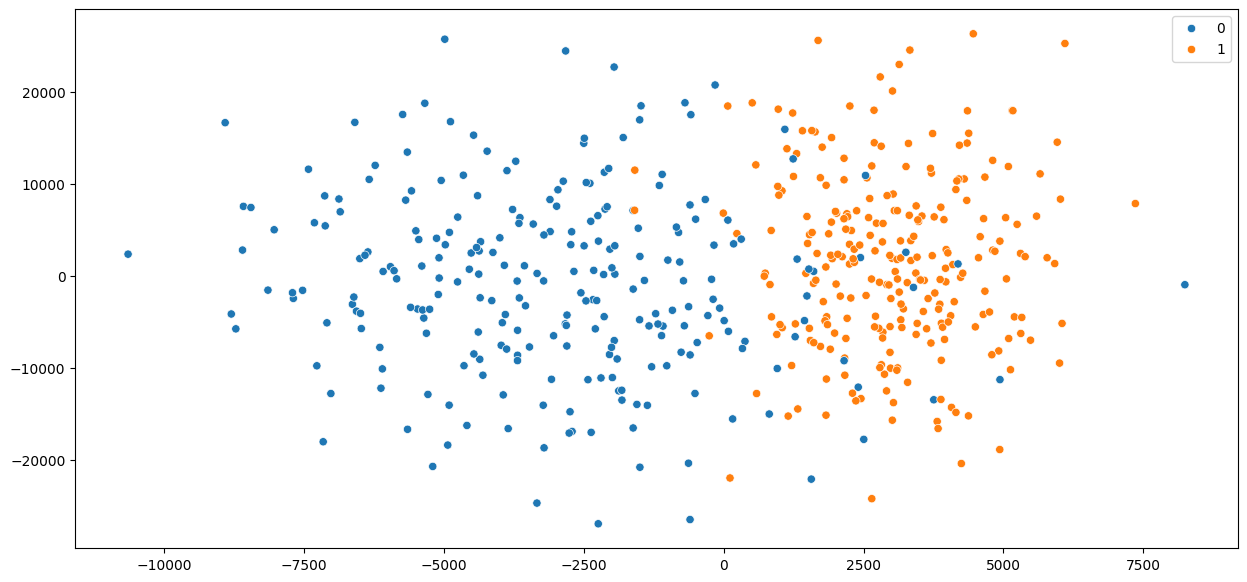

In [18]:
plt.figure(figsize=(15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.show()

<h1 class = 'markdown-google-sans'>Training without Scaling</h1>

In [21]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics=['accuracy'])

In [26]:
history = model.fit(X_train, y_train, epochs = 1000, validation_data = (X_test, y_test), verbose = 0)

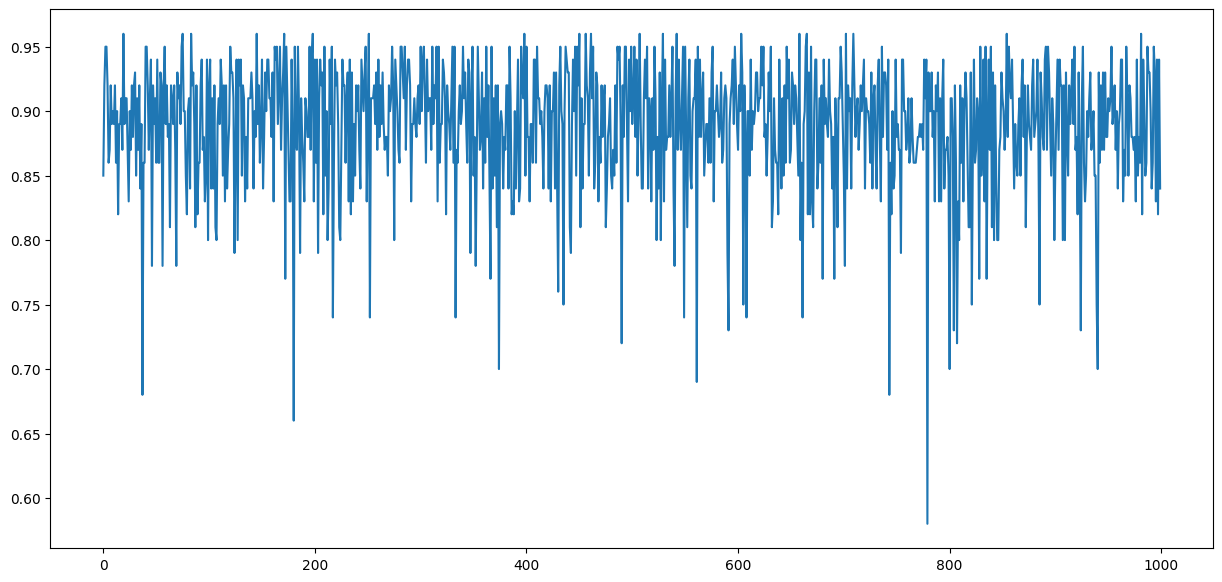

In [28]:
plt.figure(figsize = (15, 7))
plt.plot(history.history['val_accuracy'])
plt.show()

<h1 class = 'markdown-google-sans'>Training after Scaling</h1>

In [29]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
history = model.fit(X_train_scaled, y_train, epochs = 1000, validation_data = (X_test_scaled, y_test), verbose = 0)

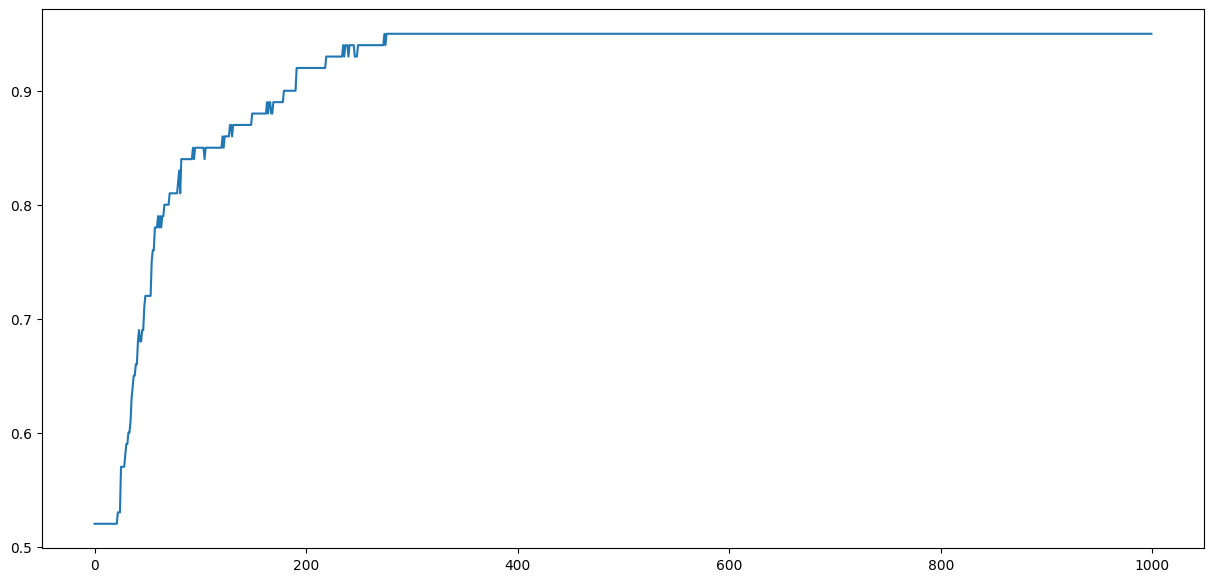

In [35]:
plt.figure(figsize = (15, 7))
plt.plot(history.history['val_accuracy'])
plt.show()